<a href="https://colab.research.google.com/github/lucasvazcastro/PA4/blob/main/aquisicao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importação de bibliotecas


In [1]:
import pandas as pd
import os
import numpy as np


# Importação dos arquivos e junção da base de dados estaduais

In [2]:

caminho = "bases qualidade do ar"
lista_de_diretorios = os.listdir(caminho)
print(lista_de_diretorios)

df = pd.DataFrame()
for estado in lista_de_diretorios:
    lista_arquivos = os.listdir(f"{caminho}/{estado}")
    for file in lista_arquivos:
        df_estado = pd.read_csv(f"{caminho}/{estado}/{file}", sep=",", encoding="latin-1")
        df_estado = df_estado[df_estado['Poluente'].isin(['MP10','MP2.5'])] #filtro prévio dos poluentes que serão utilizados
        df_estado['Estado'] = estado # acrescentando a infomração do estado em uma coluna
        df = pd.concat([df,df_estado])
df.head()

['BA', 'CE', 'ES', 'GO', 'MG', 'PE', 'PR', 'RJ', 'RS', 'SP']


,Data,Hora,Estacao,Codigo,Poluente,Valor,Unidade,Tipo,Estado,ï»¿Data
77945,2015-01-01,00:00,Concórdia,BA06,MP10,7.0,ug/m3,automatico,BA,NaN
77946,2015-01-01,01:00,Concórdia,BA06,MP10,6.8,ug/m3,automatico,BA,NaN
77947,2015-01-01,02:00,Concórdia,BA06,MP10,4.5,ug/m3,automatico,BA,NaN
77948,2015-01-01,03:00,Concórdia,BA06,MP10,3.4,ug/m3,automatico,BA,NaN
77949,2015-01-01,04:00,Concórdia,BA06,MP10,3.2,ug/m3,automatico,BA,NaN


Durante a importação um dos arquivos teve um problema de formatação no título da coluna de data, a qual consta como 'ï»¿Data'. Após análise, foi observado que as ocorrências em que 'ï»¿Data' está preenchido constam como valores nulo na coluna correta 'Data' e vice-versa. Sendo assim, os dados da coluna 'ï»¿Data' foram transpostos para a coluna 'Data' e 'ï»¿Data' será eliminada

In [3]:
print("Antes da correção: \n")
print(f"Valores nulos na coluna data: {df['Data'].isnull().sum()} ({df['Data'].isnull().sum()/df.shape[0]:.1%})")
print(f"Valores nulos na coluna ï»¿Data: {df['ï»¿Data'].isnull().sum()} ({df['ï»¿Data'].isnull().sum()/df.shape[0]:.1%})")
print(" ")
print(f"Valores não-nulos na coluna data: {df['Data'].notnull().sum()} ({df['Data'].notnull().sum()/df.shape[0]:.1%})")
print(f"Valores não-nulos na coluna ï»¿Data: {df['ï»¿Data'].notnull().sum()} ({df['ï»¿Data'].notnull().sum()/df.shape[0]:.1%})")


#substituição
df['Data'] = df['Data'].fillna(df['ï»¿Data'])

print("===============================================\n")
print("Após correção: \n")

print(f"Valores nulos na coluna data: {df['Data'].isnull().sum()} ({df['Data'].isnull().sum()/df.shape[0]:.1%})")
print(f"Valores nulos na coluna ï»¿Data: {df['ï»¿Data'].isnull().sum()} ({df['ï»¿Data'].isnull().sum()/df.shape[0]:.1%})")
print(" ")
print(f"Valores não-nulos na coluna data: {df['Data'].notnull().sum()} ({df['Data'].notnull().sum()/df.shape[0]:.1%})")
print(f"Valores não-nulos na coluna ï»¿Data: {df['ï»¿Data'].notnull().sum()} ({df['ï»¿Data'].notnull().sum()/df.shape[0]:.1%})")

Antes da correção: 

Valores nulos na coluna data: 107246 (0.8%)
Valores nulos na coluna ï»¿Data: 12966129 (99.2%)
 
Valores não-nulos na coluna data: 12966129 (99.2%)
Valores não-nulos na coluna ï»¿Data: 107246 (0.8%)

Após correção: 

Valores nulos na coluna data: 0 (0.0%)
Valores nulos na coluna ï»¿Data: 12966129 (99.2%)
 
Valores não-nulos na coluna data: 13073375 (100.0%)
Valores não-nulos na coluna ï»¿Data: 107246 (0.8%)


# Otimização de memória

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13073375 entries, 77945 to 808196
Data columns (total 10 columns):
 #   Column    Dtype  
---  ------    -----  
 0   Data      object 
 1   Hora      object 
 2   Estacao   object 
 3   Codigo    object 
 4   Poluente  object 
 5   Valor     float64
 6   Unidade   object 
 7   Tipo      object 
 8   Estado    object 
 9   ï»¿Data   object 
dtypes: float64(1), object(9)
memory usage: 1.1+ GB


### Atributos numéricos

In [5]:
print(f"Valores máximo e mínimo da coluna df['Valor']:\nvalor máximo = {df['Valor'].max()}\nvalor mínimo = {df['Valor'].min()}")

Valores máximo e mínimo da coluna df['Valor']:
valor máximo = 2723.3
valor mínimo = 0.0


In [6]:
df['Valor'] = df['Valor'].astype(np.float64)

Apesar do valor máximo não ser tão alto, optamos pela tipagem do dado numérico como float64, devido a problemas de compatibilidade com alguns méotodos do pandas com os tipos float16 ou float32.

### Atributos categóricos

In [7]:
df['Estacao'] = df['Estacao'].astype('category')
df['Poluente'] = df['Poluente'].astype('category')
df['Unidade'] = df['Unidade'].astype('category')
df['Tipo'] = df['Tipo'].astype('category')
df['Estado'] = df['Estado'].astype('category')

### Atributos temporais (data e hora)

Observamos que alguns horários estão como 24h, então será feita a substituição para 00:00:00 e 00:00 a depender do formato de cada célula.

In [8]:
print((df["Hora"] == "24:00:00").sum())
print((df["Hora"] == " 24:00:00").sum())
print((df["Hora"] == "24:00:00 ").sum())

print((df["Hora"] == "24:00").sum())
print((df["Hora"] == " 24:00").sum())
print((df["Hora"] == "24:00 ").sum())

14905
0
0
128407
0
0


In [9]:
mask = df["Hora"] == "24:00:00"
print(f"{mask.sum()} registros com o valor 24:00:00")
mask2 = df["Hora"] == "24:00"
print(f"{mask2.sum()} registros com o valor 24:00")

14905 registros com o valor 24:00:00
128407 registros com o valor 24:00


In [10]:
df.loc[mask, "Hora"] = "00:00:00"
df.loc[mask2, "Hora"] = "00:00"

Foram criados os objetos mask e mask2, pois precisaremos usar a referência dos índices em que houve correção da hora para somar 1 dia na data correspondente, já que observamos que os valores 24:00:00 e 24:00 correspondem às 00:00 do dia subsequente, conforme observado abaixo:

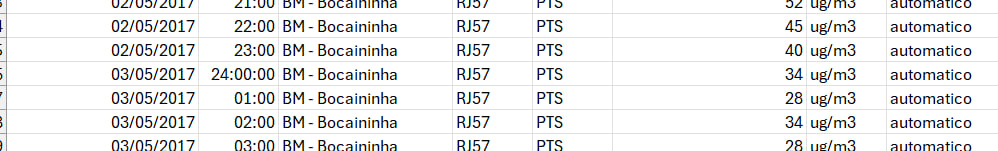

Obs: o somatório do dia será feito após a correção do formato da hora e criação da coluna Data_hora para evitar erros na conversão da data para o formato datetime, já que o problema dos campos com tamanho 00:00 vs. 00:00:00 ainda precisa ser tratado

In [11]:
# verificação da operação de correção do horário da meia noite
print(f"{(df["Hora"] == "24:00:00").sum()} registros com o valor 24:00:00")
print(f"{(df["Hora"] == "24:00").sum()} registros com o valor 24:00")
print(f"{(df["Hora"] == "00:00:00").sum()} registros com o valor 00:00:00")
print(f"{(df["Hora"] == "00:00").sum()} registros com o valor 00:00")

0 registros com o valor 24:00:00
0 registros com o valor 24:00
54388 registros com o valor 00:00:00
180596 registros com o valor 00:00


Como mencionado acima, alguns horários estão no formato de horas, minutos e segundos, enquanto outros estão apenas como horas e minutos. As ocorrências que se enquadram neste último caso, serão completadas com 00 segundos a fim de uniformizá-las antes da conversão para datetime.

In [12]:
# criação do atributo auxiliar tamanho_hora para verificação da situação descrita acima
df['tamanho_hora'] = df['Hora'].str.len()
print(df['tamanho_hora'].value_counts())


tamanho_hora
5    11799108
8     1274267
Name: count, dtype: int64


In [13]:
mask3 = df["Hora"].str.len() == 5
df.loc[mask3, "Hora"] = df.loc[mask3, "Hora"].astype(str) + ":00"

In [14]:
# verificação da correção
df['tamanho_hora2'] = df['Hora'].str.len()
print(df['tamanho_hora2'].value_counts())

tamanho_hora2
8    13073375
Name: count, dtype: int64


Criação da coluna Data_hora com o somatório das colunas data + horas separadamente.

In [15]:
df['Data_hora'] = df['Data']+ " " + df['Hora']


Verificação se todos as células ficaram uniformes

In [16]:
df['tamanho_hora3'] = df['Data_hora'].str.len()
print(df['tamanho_hora3'].value_counts())

tamanho_hora3
19    13073375
Name: count, dtype: int64


Conversão para o tipo datetime

In [17]:
df['Data_hora'] = pd.to_datetime(df['Data_hora'])

Somatório de 1 dia nas datas das ocorrências cujos índices correspondem a mask e mask2

In [18]:
df.loc[mask, "Data_hora"] = pd.to_datetime(df.loc[mask, "Data_hora"]) + pd.Timedelta(days=1)
df.loc[mask2, "Data_hora"] = pd.to_datetime(df.loc[mask2, "Data_hora"]) + pd.Timedelta(days=1)


Verificação das colunas

In [19]:
df.columns

Index(['Data', 'Hora', 'Estacao', 'Codigo', 'Poluente', 'Valor', 'Unidade',
       'Tipo', 'Estado', 'ï»¿Data', 'tamanho_hora', 'tamanho_hora2',
       'Data_hora', 'tamanho_hora3'],
      dtype='object')

Eliminação das colunas que não serão usadas

In [20]:
df = df.drop(columns=['Data','Hora','ï»¿Data', 'tamanho_hora', 'tamanho_hora2','tamanho_hora3'])

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13073375 entries, 77945 to 808196
Data columns (total 8 columns):
 #   Column     Dtype         
---  ------     -----         
 0   Estacao    category      
 1   Codigo     object        
 2   Poluente   category      
 3   Valor      float64       
 4   Unidade    category      
 5   Tipo       category      
 6   Estado     category      
 7   Data_hora  datetime64[ns]
dtypes: category(5), datetime64[ns](1), float64(1), object(1)
memory usage: 473.8+ MB


## Remoção de valores duplicados

In [22]:
print(f"A base possui {df.duplicated().sum()} ocorrências duplicadas (que apareceram mais de uma vez)")
duplicados = df[df.duplicated(keep=False)] # Ocorrências salvas no dataframe duplicados para análise
linhas_antes_remocao = df.shape[0]
print("Linhas antes da remoção de duplicatas :", linhas_antes_remocao)
df = df.drop_duplicates()
linhas_apos_remocao = df.shape[0]
print("Linhas após a remoção de duplicatas :", linhas_apos_remocao)



A base possui 27682 ocorrências duplicadas (que apareceram mais de uma vez)
Linhas antes da remoção de duplicatas : 13073375
Linhas após a remoção de duplicatas : 13045693


In [23]:
duplicados.to_excel("duplicados.xlsx")

## Remoção de valores nulos

In [24]:
df.isnull().sum()

Estacao          0
Codigo       71798
Poluente         0
Valor           65
Unidade          0
Tipo             0
Estado           0
Data_hora        0
dtype: int64

In [25]:
campo_valor_nulos = df[df['Valor'].isna()]

Foi verificado que de fato se trata de valores nulos nos arquivos originais
**exemplo**:
![image.png](attachment:image.png)


In [26]:
df = df.dropna() #remoção dos valores nulos, pois de fato não existem nos arquivos principais

In [27]:
campo_codigo_nulos = df[df['Codigo'].isna()]
estacoes_sem_codigo = ", ".join(campo_codigo_nulos['Estacao'].unique())
print(f"Verificado nos arquivos originais que as estações {estacoes_sem_codigo} realmente não possuem código e constam como 'NA' nos arquivos originais")

Verificado nos arquivos originais que as estações  realmente não possuem código e constam como 'NA' nos arquivos originais


Em decorrência de algumas estações não possuírem código, optou-se por usar a coluna Estação que está completa e eliminação da coluna código
**exemplo**:
![image.png](attachment:image.png)

In [28]:
df = df.drop(columns=['Codigo'])

In [29]:
# Verificação se ainda há alguma ocorrência de valores nulos
df.isnull().sum()

Estacao      0
Poluente     0
Valor        0
Unidade      0
Tipo         0
Estado       0
Data_hora    0
dtype: int64

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12973830 entries, 77945 to 808196
Data columns (total 7 columns):
 #   Column     Dtype         
---  ------     -----         
 0   Estacao    category      
 1   Poluente   category      
 2   Valor      float64       
 3   Unidade    category      
 4   Tipo       category      
 5   Estado     category      
 6   Data_hora  datetime64[ns]
dtypes: category(5), datetime64[ns](1), float64(1)
memory usage: 371.2 MB


#### Correção do atributo Tipo

In [31]:
df['Tipo'].value_counts()

Tipo
automatica    6191137
Automático    3955184
automatico    1297322
automático     759157
Automatico     687197
Automática      69415
manual          11714
Manual           2704
Name: count, dtype: int64

In [32]:
dic_correcao = {"automatica": "automatico",
                "Automático": "automatico",
                "automático": "automatico",
                "Automatico": "automatico",
                "Automática": "automatico",
                "Manual": "manual"}
df['Tipo'] = df['Tipo'].replace(dic_correcao)

C:\Users\lucas\AppData\Local\Temp\ipykernel_22472\578917221.py:7: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df['Tipo'] = df['Tipo'].replace(dic_correcao)


In [33]:
#verificação da correção
df['Tipo'].value_counts()

Tipo
automatico    12959412
manual           14418
Name: count, dtype: int64

In [34]:
df_manual = df[df['Tipo'] == 'manual'] 

Após análise, optamos por manter o tipo de coleta manual

#### Análise do atributo unidade

In [35]:
df['Unidade'].value_counts()

Unidade
ug/m3      7652300
µg/m3      4667508
µg/m³       637749
Âµg/mÂ³      16273
Name: count, dtype: int64

Apesar de diferenças na formatação, a unidade para os poluentes MP10 e MP2.5 é sempre micrograma por metro cúbico. Sendo assim, a coluna será removida

In [36]:
df = df.drop(columns=['Unidade'])

Estatíticas descritivas dos atributos numéricos restantes:

In [ ]:
df.describe() 

,Valor,Data_hora
count,1.297383e+07,12973830
mean,2.553054e+01,2019-03-28 02:36:29.791982848
min,0.000000e+00,2015-01-01 00:00:00
25%,1.000000e+01,2017-05-06 23:55:00
50%,1.900000e+01,2019-05-23 09:00:00
75%,3.200000e+01,2021-03-15 12:30:00
max,2.723300e+03,2023-01-01 00:00:00
std,3.192380e+01,NaN


Dimensão do dataframe final

In [38]:
df.shape

(12973830, 6)

In [39]:
df.to_csv('df.csv')